In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math

In [10]:
import networkx as nx

class AttackGraph:
    def __init__(self):
        self.G = nx.DiGraph()

    def add_node(self, name, layer, cvss):
        """Add node with layer and CVSS score (0-1)"""
        self.G.add_node(name, layer=layer, cvss=cvss)

    def add_edge(self, src, dst, asr):
        """Add edge with Attack Success Rate (0-1)"""
        self.G.add_edge(src, dst, asr=asr)


In [11]:
# Create example graph
ag = AttackGraph()

# Nodes: External, Internal, Core
ag.add_node("Web_Gateway", layer="External", cvss=0.3)
ag.add_node("Auth_Service", layer="Internal", cvss=0.5)
ag.add_node("User_DB", layer="Core", cvss=0.7)

# Edges with ASR (Attack Success Rate)
ag.add_edge("Web_Gateway", "Auth_Service", asr=0.6)
ag.add_edge("Auth_Service", "User_DB", asr=0.2)
ag.add_edge("Web_Gateway", "User_DB", asr=0.1)  # optional direct attack


In [12]:

def most_likely_attack_path(G, start, target):
    """Find path with maximum probability from start to target"""
    transformed = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        # Transform probability to weight for Dijkstra: weight = -log(prob)
        transformed.add_edge(u, v, weight=-math.log(data['asr']))
    
    path = nx.dijkstra_path(transformed, start, target, weight='weight')
    
    # Calculate overall probability of this path
    probability = 1
    for i in range(len(path)-1):
        probability *= G[path[i]][path[i+1]]['asr']
    
    return path, probability

# Example usage
mlap_path, mlap_prob = most_likely_attack_path(ag.G, "Web_Gateway", "User_DB")
print("MLAP Path:", mlap_path)
print("MLAP Probability:", round(mlap_prob, 4))



MLAP Path: ['Web_Gateway', 'Auth_Service', 'User_DB']
MLAP Probability: 0.12


In [13]:
# run N=1000 simulations and compute the percentage of success reaching the User_DB (Target).

def monte_carlo_simulation(G, start, target, iterations=1000):
    """Simulate attacker N times and return success rate"""
    success = 0
    for _ in range(iterations):
        current = start
        visited = set()
        while current != target:
            visited.add(current)
            neighbors = [n for n in G.successors(current) if n not in visited]
            if not neighbors:
                break
            probs = [G[current][n]['asr'] for n in neighbors]
            total = sum(probs)
            probs = [p/total for p in probs]
            current = random.choices(neighbors, weights=probs, k=1)[0]
        if current == target:
            success += 1
    return success / iterations

# Run Monte Carlo N=1000 times
monte_carlo_prob = monte_carlo_simulation(ag.G, "Web_Gateway", "User_DB", iterations=1000)
print("Monte Carlo Success Rate (1000 runs):", round(monte_carlo_prob, 4))


Monte Carlo Success Rate (1000 runs): 1.0


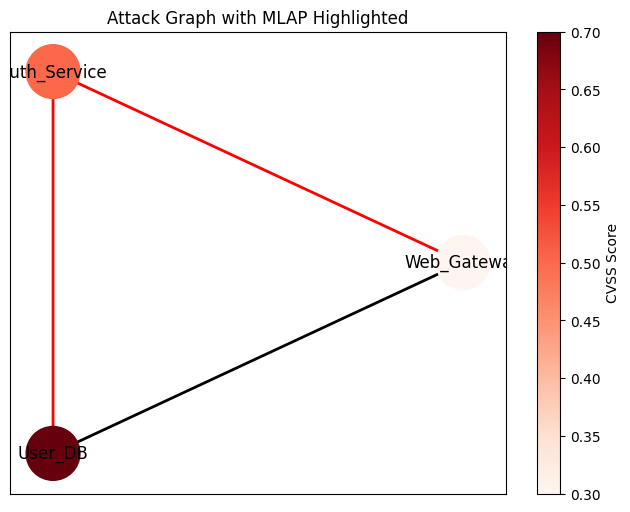

In [19]:
# Draw the Graph and highlight MLAP path
def draw_attack_graph(G, critical_path=[]):
    pos = nx.kamada_kawai_layout(G)
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    # Highlight MLAP path
    critical_edges = [(critical_path[i], critical_path[i+1]) 
                      for i in range(len(critical_path)-1)]
    
    edge_colors = ['red' if (u,v) in critical_edges else 'black' 
                   for u,v in G.edges()]
    
    node_colors = [G.nodes[n]['cvss'] for n in G.nodes()]
    
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        cmap=plt.cm.Reds,
        node_size=1500,
        ax=ax
    )
    
    nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        width=2,
        ax=ax
    )
    
    nx.draw_networkx_labels(G, pos, ax=ax)
    
    # Proper colorbar connection
    cbar = fig.colorbar(nodes, ax=ax)
    cbar.set_label("CVSS Score")
    
    plt.title("Attack Graph with MLAP Highlighted")
    plt.show()


# Draw graph with MLAP highlighted
draw_attack_graph(ag.G, mlap_path)


In [20]:
# Build Flat Network (High Connectivity, Low Security)

# A flat network means:

# Many direct connections
# High ASR values
# Almost everything can talk to everything

def build_flat_network():
    G = nx.DiGraph()

    # Nodes
    services = {
        "Web_Gateway": 0.3,
        "Auth_Service": 0.5,
        "Payment_Service": 0.6,
        "Order_Service": 0.4,
        "User_DB": 0.7,
        "Payment_DB": 0.8
    }

    for node, cvss in services.items():
        G.add_node(node, cvss=cvss)

    # High connectivity (almost fully connected)
    for src in services:
        for dst in services:
            if src != dst:
                G.add_edge(src, dst, asr=0.6)

    return G

flat_G = build_flat_network()


In [6]:
# Build Zero-Trust Network

# Zero-Trust means:
# Only necessary communication allowed
# Internal segmentation
# Reduced ASR for protected paths

from networkx.algorithms import community

def build_zero_trust_network(flat_G):
    G = flat_G.copy()

    # Detect communities
    communities = community.greedy_modularity_communities(G.to_undirected())

    # Remove cross-community edges
    for comm in communities:
        comm = list(comm)
        for u in G.nodes():
            for v in G.nodes():
                if u in comm and v not in comm:
                    if G.has_edge(u, v):
                        G.remove_edge(u, v)

    # Reduce ASR for remaining edges (stronger security)
    for u, v in G.edges():
        G[u][v]['asr'] *= 0.3   # Apply security hardening

    return G

zero_G = build_zero_trust_network(flat_G)



In [21]:
from networkx.algorithms import community

def build_zero_trust_network(flat_G):
    G = flat_G.copy()

    # Detect communities
    communities = community.greedy_modularity_communities(G.to_undirected())

    # Remove cross-community edges
    for comm in communities:
        comm = list(comm)
        for u in G.nodes():
            for v in G.nodes():
                if u in comm and v not in comm:
                    if G.has_edge(u, v):
                        G.remove_edge(u, v)

    # Reduce ASR for remaining edges (stronger security)
    for u, v in G.edges():
        G[u][v]['asr'] *= 0.3   # Apply security hardening

    return G

zero_G = build_zero_trust_network(flat_G)



In [22]:
# ==========================================================
# METRIC 1: Network Blast Radius
# ==========================================================
# Blast Radius = Number of nodes reachable from attacker's entry point.
# It measures how much of the system can be compromised if the attacker starts from a specific node.

def blast_radius(G, start):
    """
    Calculate the number of nodes reachable from the start node.
    Uses graph descendants (forward reachable nodes).
    """
    reachable_nodes = nx.descendants(G, start)
    return len(reachable_nodes)


# Compute Blast Radius for both architectures
flat_blast = blast_radius(flat_G, "Web_Gateway")
zero_blast = blast_radius(zero_G, "Web_Gateway")

print("========== Network Blast Radius ==========")
print("Flat Network Blast Radius:", flat_blast)
print("Zero-Trust Network Blast Radius:", zero_blast)


========== Network Blast Radius ==========
Flat Network Blast Radius: 5
Zero-Trust Network Blast Radius: 5


In [23]:
# ==========================================================
# METRIC 2: Overall Compromise Probability
# ==========================================================
# This metric runs Monte Carlo simulation N times.
# It measures the percentage of runs where attacker successfully reaches target.

flat_mc = monte_carlo_simulation(flat_G, "Web_Gateway", "User_DB", iterations=1000)
zero_mc = monte_carlo_simulation(zero_G, "Web_Gateway", "User_DB", iterations=1000)

print("\n========== Overall Compromise Probability ==========")
print("Flat Network Success Rate:", round(flat_mc, 4))
print("Zero-Trust Network Success Rate:", round(zero_mc, 4))



========== Overall Compromise Probability ==========
Flat Network Success Rate: 1.0
Zero-Trust Network Success Rate: 1.0


In [24]:
# ==========================================================
# METRIC 3: MLAP (Most Likely Attack Path)
# ==========================================================
# MLAP finds the single most probable attack path from entry to target.
# It represents the highest risk deterministic attack path.

flat_path, flat_mlap = most_likely_attack_path(flat_G, "Web_Gateway", "User_DB")
zero_path, zero_mlap = most_likely_attack_path(zero_G, "Web_Gateway", "User_DB")

print("\n========== MLAP Comparison ==========")
print("Flat Network MLAP Probability:", round(flat_mlap,4))
print("Flat MLAP Path:", flat_path)

print("\nZero-Trust Network MLAP Probability:", round(zero_mlap,4))
print("Zero-Trust MLAP Path:", zero_path)



========== MLAP Comparison ==========
Flat Network MLAP Probability: 0.6
Flat MLAP Path: ['Web_Gateway', 'User_DB']

Zero-Trust Network MLAP Probability: 0.18
Zero-Trust MLAP Path: ['Web_Gateway', 'User_DB']


In [25]:
# ==========================================================
# METRIC 4: RASR (Robustness-Attack Success Rate)
# ==========================================================
# RASR measures how robust the network is.
# RASR = 1 - Overall Compromise Probability

flat_rasr = 1 - flat_mc
zero_rasr = 1 - zero_mc

print("\n========== RASR (Robustness Metric) ==========")
print("Flat Network RASR:", round(flat_rasr,4))
print("Zero-Trust Network RASR:", round(zero_rasr,4))



========== RASR (Robustness Metric) ==========
Flat Network RASR: 0.0
Zero-Trust Network RASR: 0.0


In [26]:
# ==========================================================
# FINAL COMPARISON TABLE
# ==========================================================

print("\n================ FINAL ARCHITECTURE COMPARISON ================")

print("\n--- FLAT NETWORK ---")
print("Blast Radius:", flat_blast)
print("Monte Carlo Success:", round(flat_mc,4))
print("MLAP Probability:", round(flat_mlap,4))
print("RASR:", round(flat_rasr,4))

print("\n--- ZERO TRUST NETWORK ---")
print("Blast Radius:", zero_blast)
print("Monte Carlo Success:", round(zero_mc,4))
print("MLAP Probability:", round(zero_mlap,4))
print("RASR:", round(zero_rasr,4))

print("\n===============================================================")



================ FINAL ARCHITECTURE COMPARISON ================

--- FLAT NETWORK ---
Blast Radius: 5
Monte Carlo Success: 1.0
MLAP Probability: 0.6
RASR: 0.0

--- ZERO TRUST NETWORK ---
Blast Radius: 5
Monte Carlo Success: 1.0
MLAP Probability: 0.18
RASR: 0.0

